# Plant Disease Classification

**Automated identification of plant diseases from leaf images using deep learning.**

This notebook will cover:
1. **Environment Setup** Clone the repository and install dependencies
2. **Kaggle API Configuration** Authenticate and configure dataset access
3. **Dataset Preparation** Download, extract, and organize the dataset
4. **Exploratory Data Analysis** Visualize class distributions and dataset statistics

## 1. Environment Setup

Clone the project repository, set drive repository, connect drive and local directory for model results, and install all required Python packages.

In [1]:
from google.colab import drive
import os, shutil

drive.mount('/content/drive')

repo_root = "/content/PlantDiseasePredictionNN"
repo_outputs = f"{repo_root}/outputs"
drive_outputs = "/content/drive/MyDrive/PlantDiseasePredictionNN_outputs"

Mounted at /content/drive


In [2]:
# Clone the project repository
!git clone https://github.com/StefanLazarevic02/PlantDiseasePredictionNN
%cd PlantDiseasePredictionNN

Cloning into 'PlantDiseasePredictionNN'...
remote: Enumerating objects: 105, done.
remote: Counting objects: 100% (105/105), done.
remote: Compressing objects: 100% (66/66), done.
remote: Total 105 (delta 44), reused 88 (delta 27), pack-reused 0 (from 0)
Receiving objects: 100% (105/105), 11.94 MiB | 14.64 MiB/s, done.
Resolving deltas: 100% (44/44), done.
/content/PlantDiseasePredictionNN


In [3]:
if os.path.islink(repo_outputs) or os.path.exists(repo_outputs):
    try:
        os.remove(repo_outputs)
    except:
        shutil.rmtree(repo_outputs)

os.symlink(drive_outputs, repo_outputs)

print("OK:")
print(f"{repo_outputs} -> {drive_outputs}")

OK:
/content/PlantDiseasePredictionNN/outputs -> /content/drive/MyDrive/PlantDiseasePredictionNN_outputs


In [4]:
# Install all required packages
!pip install -q torch torchvision albumentations Pillow numpy pandas \
    matplotlib seaborn scikit-learn PyYAML tqdm opencv-python kaggle imagehash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 10.8 MB/s eta 0:00:00


## 2. Kaggle API Configuration

Upload your `kaggle.json` credentials file and configure the Kaggle CLI for dataset downloads.

In [5]:
# Upload kaggle.json credentials
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{\r\n  "username": "stefanlazarevic02",\r\n  "key": "KGAT_a86d048c2a6fe11726b46fb124b435b2"\r\n}'}

In [6]:
# Set up Kaggle credentials directory and permissions
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

## 3. Dataset Download & Preparation

Download the [New Plant Diseases Dataset](https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset) from Kaggle, extract it, and reorganize the test split into the correct directory structure.

In [7]:
# Download and extract the dataset
!kaggle datasets download -d 'vipoooool/new-plant-diseases-dataset'
!unzip -q new-plant-diseases-dataset.zip -d data/

Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors
100% 2.70G/2.70G [00:28<00:00, 101MB/s]



In [8]:
# Reorganize directory structure: move test split and clean up duplicates
%cd data
!rm -rf "new plant diseases dataset(augmented)"
!mv "test/test" "New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/"
!rm -rf "test"
%cd ..

/content/PlantDiseasePredictionNN/data
/content/PlantDiseasePredictionNN


## 4. Exploratory Data Analysis

Examine the dataset structure, class distribution, and basic statistics before training.

### 4.1 Creating DataFrame
Build `df` with image path, class label, and split; verify shapes, head, split counts, and class count.

In [9]:
from pathlib import Path
import pandas as pd
import numpy as np

ROOT = Path(".").resolve()
DATA_ROOT = ROOT / "data" / "New Plant Diseases Dataset(Augmented)" / "New Plant Diseases Dataset(Augmented)"

if not DATA_ROOT.exists():
    raise FileNotFoundError(
        f"Path doesnt exist: {DATA_ROOT}\n"
        "Chech if root is active in Jupyter file."
    )

splits = ["train", "valid", "test"]
exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

rows = []
for split in splits:
    split_dir = DATA_ROOT / split
    if not split_dir.exists():
        print(f"[WARN] Split folder doesnt exist: {split_dir}")
        continue

    for class_dir in split_dir.iterdir():
        if not class_dir.is_dir():
            continue
        label = class_dir.name

        for img_path in class_dir.rglob("*"):
            if img_path.suffix.lower() in exts:
                rows.append({
                    "image_path": str(img_path),
                    "label": label,
                    "split": split
                })

df = pd.DataFrame(rows)

if df.empty:
    raise ValueError("DataFrame is empty.")

print("df created")
print("Shape:", df.shape)
display(df.head(5))

print("\nSplit distribution:")
display(df["split"].value_counts())

print("\nNumber of classes:", df["label"].nunique())

df created
Shape: (87867, 3)


,image_path,label,split
0,/content/PlantDiseasePredictionNN/data/New Pla...,Tomato___Tomato_mosaic_virus,train
1,/content/PlantDiseasePredictionNN/data/New Pla...,Tomato___Tomato_mosaic_virus,train
2,/content/PlantDiseasePredictionNN/data/New Pla...,Tomato___Tomato_mosaic_virus,train
3,/content/PlantDiseasePredictionNN/data/New Pla...,Tomato___Tomato_mosaic_virus,train
4,/content/PlantDiseasePredictionNN/data/New Pla...,Tomato___Tomato_mosaic_virus,train



Split distribution:


,count
split,
train,70295
valid,17572



Number of classes: 38


U ovom koraku formira se centralni DataFrame koji povezuje svaku sliku sa klasom i splitom (`train`, `valid`, `test`).
Na taj način se svi podaci dovode u jedinstven tabelarni format koji je pogodan za dalju analizu i proveru kvaliteta.
Odmah se proverava da li je tabela uspešno popunjena, koliko ima redova i da li je raspodela po splitovima očekivana.
Ovo je osnov za sve naredne EDA korake, jer se sve metrike računaju nad istim `df` objektom.

### 4.2 DatasetAnalyzer summary
Loads config paths, prints dataset stats, and plots class distribution for train/valid using the helper class.

NEW PLANT DISEASES DATASET - ANALYSIS

TRAIN SET:
Classes: 38
Total images: 70,295
Min per class: 1,642
Max per class: 2,022
Mean per class: 1850
Std per class: 106

VALID SET:
Classes: 38
Total images: 17,572
Min per class: 410
Max per class: 505
Mean per class: 462
Std per class: 26
PLANT SPECIES (14):
   Apple                               | 4 classes | 3 diseases | 7,771 images
   Blueberry                           | 1 classes | 0 diseases | 1,816 images
   Cherry (including sour)             | 2 classes | 1 diseases | 3,509 images
   Corn (maize)                        | 4 classes | 3 diseases | 7,316 images
   Grape                               | 4 classes | 3 diseases | 7,222 images
   Orange                              | 1 classes | 1 diseases | 2,010 images
   Peach                               | 2 classes | 1 diseases | 3,566 images
   Pepper, bell                        | 2 classes | 1 diseases | 3,901 images
   Potato                              | 3 classes | 2 disease

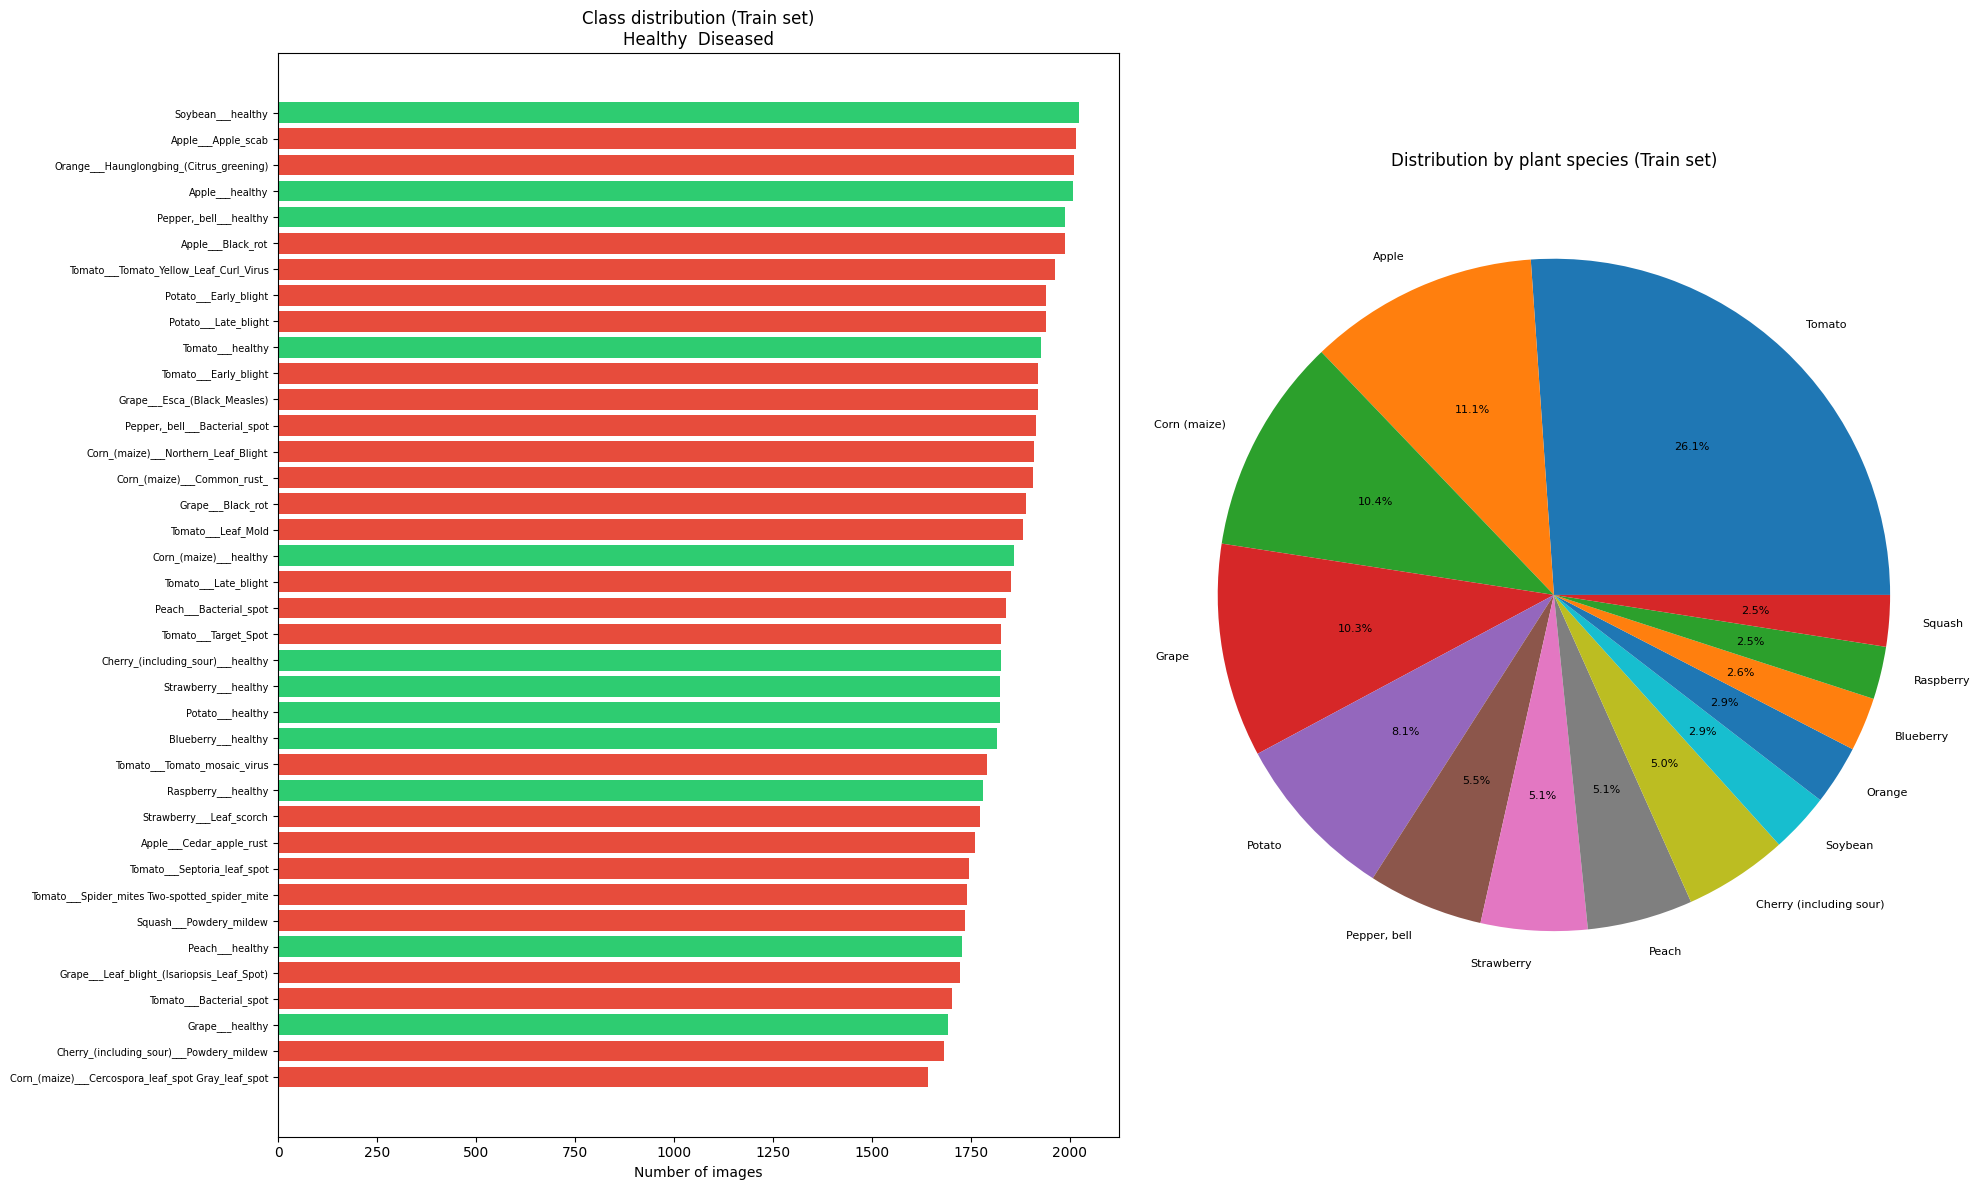

In [10]:
import yaml
from src.preprocessing.dataset_analyzer import DatasetAnalyzer

# Load configuration
with open("config/config.yaml", "r") as f:
    config = yaml.safe_load(f)

# Initialize dataset analyzer
analyzer = DatasetAnalyzer(
    root_dir=config["dataset"]["root_dir"],
    train_dir=config["dataset"]["train_dir"],
    valid_dir=config["dataset"]["valid_dir"],
)

# Print dataset summary statistics
analyzer.print_summary()

# Plot class distribution across train and validation splits
analyzer.plot_distribution(save_path="outputs/class_distribution.png")

Ovde se koristi `DatasetAnalyzer` da brzo prikaže ključne statistike skupa podataka po splitovima i klasama.
Dobijamo pregled broja slika, broj klasa i osnovne pokazatelje raspodele koji su važni pre treninga modela.
Pored tekstualnog pregleda, crta se i distribucija klasa radi vizuelne provere balansa skupa.
Ovaj korak služi kao sanity check da je struktura podataka stabilna i spremna za naredne analize.

### 4.3 Health check + distributions + dimensions
Null/duplicate scan, class distribution barplot, split-vs-class heatmap, and image dimension stats (width/height/area/aspect).

Shape: (87867, 3)
Duplicate rows: 0


,0
image_path,0
label,0
split,0


,count
label,
Soybean___healthy,2527
Apple___Apple_scab,2520
Orange___Haunglongbing_(Citrus_greening),2513
Apple___healthy,2510
"Pepper,_bell___healthy",2485
Apple___Black_rot,2484
Tomato___Tomato_Yellow_Leaf_Curl_Virus,2451
Potato___Late_blight,2424
Potato___Early_blight,2424


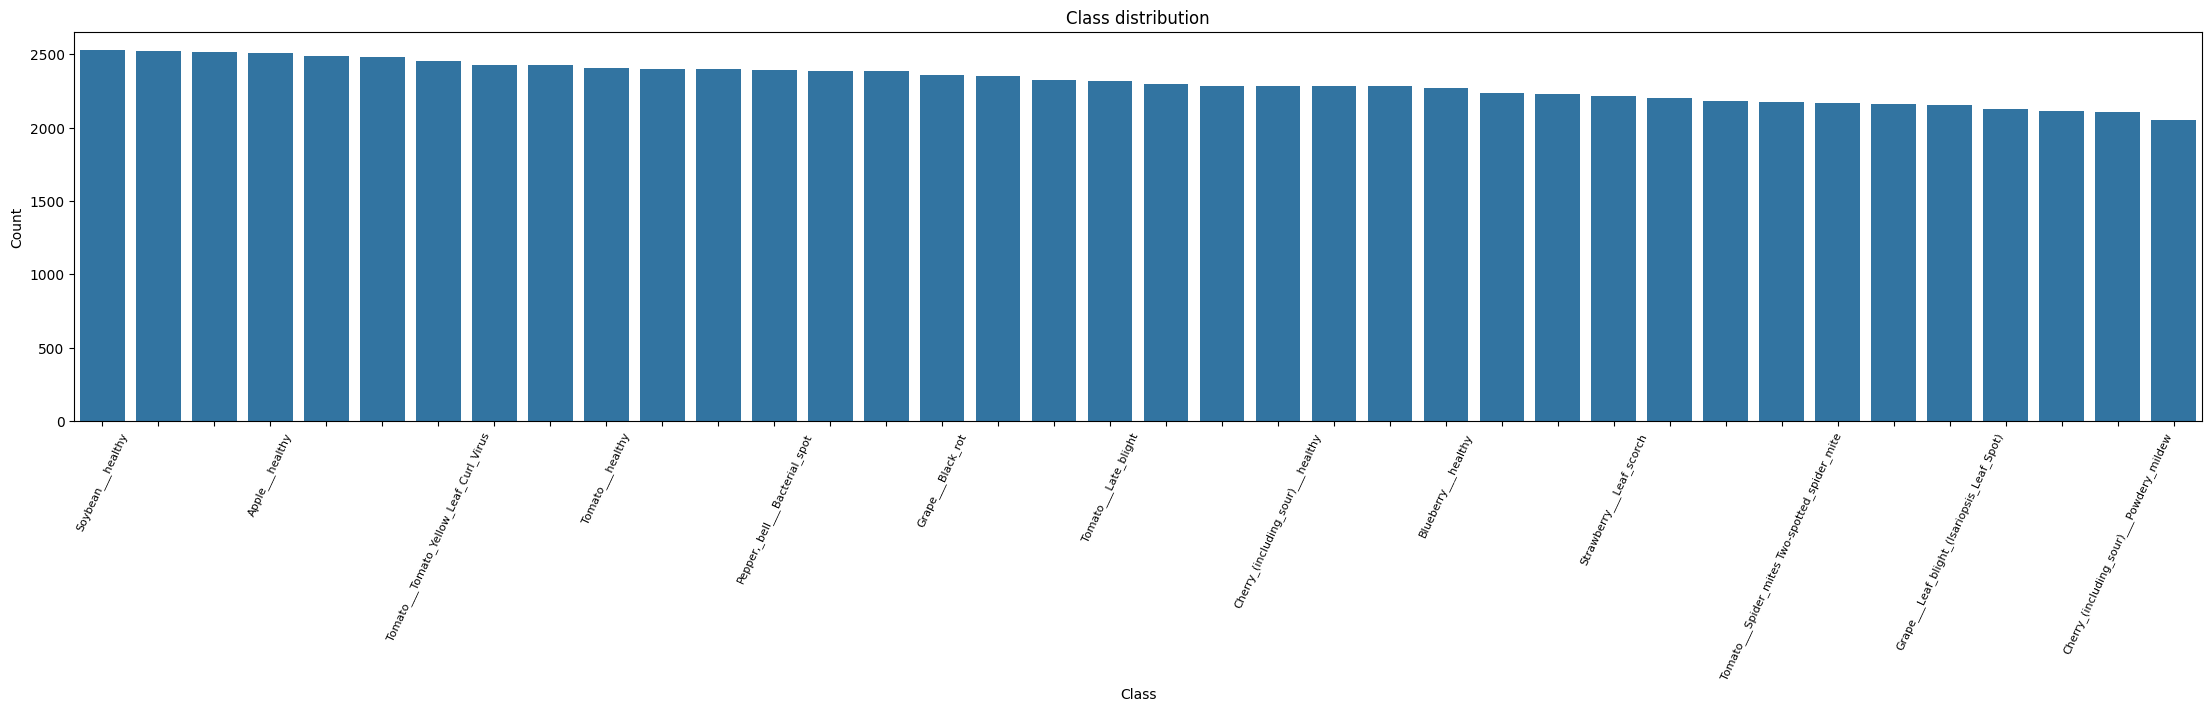

/tmp/ipykernel_2586/2287427369.py:37: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


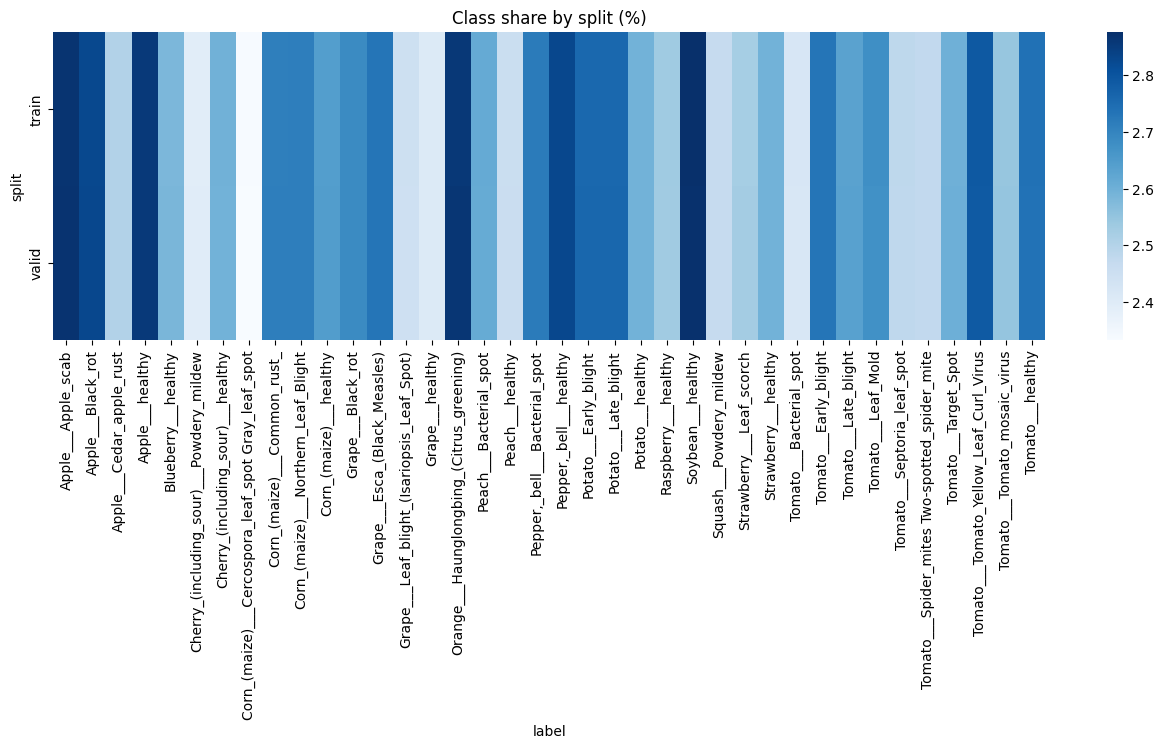

Images failed to load: 0


,img_width,img_height,img_area,aspect_ratio
count,87867.0,87867.0,87867.0,87867.0
mean,256.0,256.0,65536.0,1.0
std,0.0,0.0,0.0,0.0
min,256.0,256.0,65536.0,1.0
25%,256.0,256.0,65536.0,1.0
50%,256.0,256.0,65536.0,1.0
75%,256.0,256.0,65536.0,1.0
max,256.0,256.0,65536.0,1.0


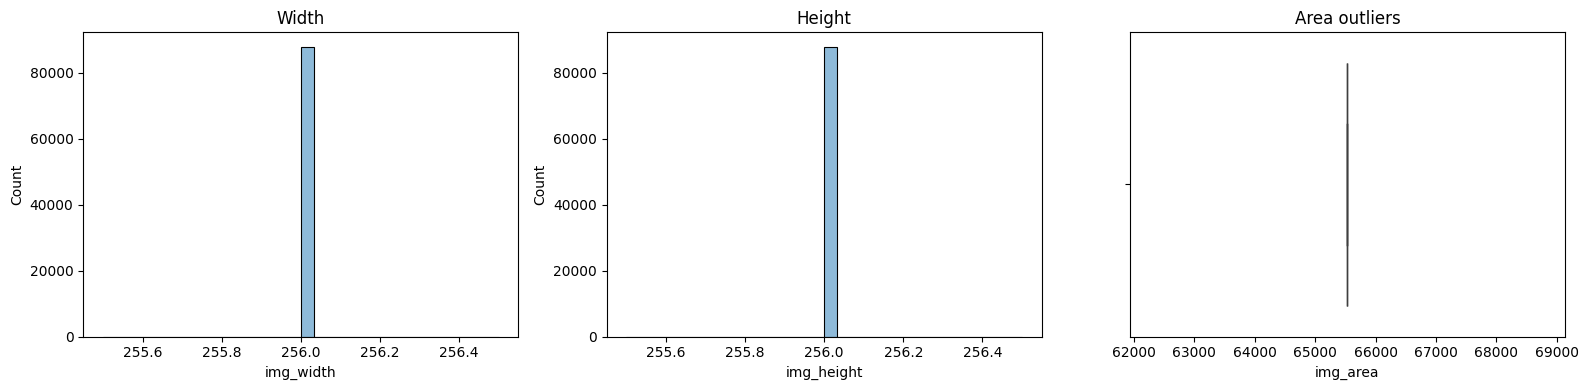

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm
import numpy as np

tqdm.pandas()

print("Shape:", df.shape)
print("Duplicate rows:", df.duplicated().sum())
display(df.isnull().sum().sort_values(ascending=False).head(10))

# Class distribution
class_counts = df["label"].value_counts()
display(class_counts.head(20))

fig, ax = plt.subplots(figsize=(22, 7), constrained_layout=True)
sns.countplot(data=df, x="label", order=class_counts.index, ax=ax)

ax.set_title("Class distribution")
ax.set_xlabel("Class")
ax.set_ylabel("Count")
ax.tick_params(axis="x", labelrotation=65, labelsize=8)

n = 3
for i, label in enumerate(ax.get_xticklabels()):
    if i % n != 0:
        label.set_visible(False)

plt.show()

# Split x class (%)
split_class = pd.crosstab(df["split"], df["label"], normalize="index") * 100
plt.figure(figsize=(16,4))
sns.heatmap(split_class, cmap="Blues")
plt.title("Class share by split (%)")
plt.tight_layout()
plt.show()

# Image dimensions
def get_img_size(path):
    try:
        with Image.open(path) as im:
            return im.size  # (w, h)
    except Exception:
        return (np.nan, np.nan)

sizes = df["image_path"].apply(get_img_size)

df["img_width"] = sizes.apply(lambda x: x[0])
df["img_height"] = sizes.apply(lambda x: x[1])
df["img_area"] = df["img_width"] * df["img_height"]
df["aspect_ratio"] = df["img_width"] / df["img_height"]

print("Images failed to load:", df["img_width"].isna().sum())
display(df[["img_width", "img_height", "img_area", "aspect_ratio"]].describe())

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(df["img_width"].dropna(), bins=30, kde=True, ax=axes[0]); axes[0].set_title("Width")
sns.histplot(df["img_height"].dropna(), bins=30, kde=True, ax=axes[1]); axes[1].set_title("Height")
sns.boxplot(x=df["img_area"].dropna(), ax=axes[2]); axes[2].set_title("Area outliers")
plt.tight_layout()
plt.show()

Prvo se prikaze sadrzaj DataFrame-a, tj koliko elemenata ima u njemu. Zatim se prikaze broj duplikata po nazivu elementa.
Prikazuje tabelu top klasa po ucestalosti.
Nakon toga prikazuje bar-plot raspodele elemenata po klasama.
Slika "Class share by split" objasnjava da redovi train i valid izgledaju skoro isto po kolonama, iz cega zakljucujemo da je odnos klasa slican u train i valid. Vrijednosti su uglavnom izmedju 2.4% i 2.9%, sto znaci da je dataset prilicno balansiran.
Nakon toga, sledi tabela u kojoj su proracunate dimenzije slike i vidimo da su sve 256x256 piksela (sto se takodje vidi i na grafiku). Desni grafik prikazuje Area outliers i vidimo da je koncentrisana oko 65 hiljada, sa vrlo malim odstupanjima.

### 4.4 Per-split class uniformity
Cross-tab by split and label, plus entropy per split (higher = more even class mix).

In [ ]:
split_class_pct = pd.crosstab(df["split"], df["label"], normalize="index") * 100
display(split_class_pct.round(2))

def entropy(row):
    p = row.values / row.values.sum()
    p = p[p > 0]
    return -(p * np.log2(p)).sum()

split_class_counts = pd.crosstab(df["split"], df["label"])
split_entropy = split_class_counts.apply(entropy, axis=1).rename("entropy")
print("Entropy per split:")
display(split_entropy)

label,Apple___Apple_scab,Apple___Black_rot,Apple___Cedar_apple_rust,Apple___healthy,Blueberry___healthy,Cherry_(including_sour)___Powdery_mildew,Cherry_(including_sour)___healthy,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot,Corn_(maize)___Common_rust_,Corn_(maize)___Northern_Leaf_Blight,...,Tomato___Bacterial_spot,Tomato___Early_blight,Tomato___Late_blight,Tomato___Leaf_Mold,Tomato___Septoria_leaf_spot,Tomato___Spider_mites Two-spotted_spider_mite,Tomato___Target_Spot,Tomato___Tomato_Yellow_Leaf_Curl_Virus,Tomato___Tomato_mosaic_virus,Tomato___healthy
split,,,,,,,,,,,,,,,,,,,,,
train,2.87,2.83,2.5,2.86,2.58,2.39,2.6,2.34,2.71,2.71,...,2.42,2.73,2.63,2.68,2.48,2.48,2.6,2.79,2.55,2.74
valid,2.87,2.83,2.5,2.86,2.58,2.40,2.6,2.33,2.71,2.71,...,2.42,2.73,2.63,2.67,2.48,2.48,2.6,2.79,2.55,2.74


Entropy per split:


,entropy
split,
train,5.245628
valid,5.245618


Ovde se kvantitativno proverava koliko su klase ravnomerno raspoređene unutar svakog splita.
Tabela procenata omogućava direktno poređenje `train` i `valid` skupa po svakoj klasi.
Dodatno, entropija po splitu daje zbirni pokazatelj ujednačenosti raspodele.
Slične vrednosti entropije ukazuju na to da je raspodela klasa između skupova uravnotežena i konzistentna.

### 4.5 Duplicate checks
Quick sanity checks for duplicate paths and repeated filenames across splits.

In [ ]:
# Potential duplicates by path and filename
# 1. Duplicate full paths
dup_path = df.duplicated(subset=["image_path"]).sum()
print("Duplicate image_path:", dup_path)

# 2. Same filename across folders (not always an issue, but worth checking)
df["file_name"] = df["image_path"].apply(lambda p: p.split("/")[-1])
same_name = df["file_name"].value_counts()
same_name_multi = same_name[same_name > 1]

print("Filenames appearing more than once:", len(same_name_multi))
display(same_name_multi.head(20))

Duplicate image_path: 0
Filenames appearing more than once: 0


,count
file_name,


U ovom koraku proveravaju se potencijalni duplikati na dva nivoa: po punoj putanji i po imenu fajla.
Duplikati putanje ukazuju na potpuno isti uzorak, dok ponovljena imena mogu signalizirati moguće preklapanje između foldera.
Iako ista imena ne moraju biti greška, korisno je identifikovati ih pre treniranja modela.
Cilj je da se smanji rizik od nerealno dobrih rezultata validacije.

### 4.6 Quick visual sample
Draw a 3x3 sample (first 9 classes) to eyeball data quality and split labels.

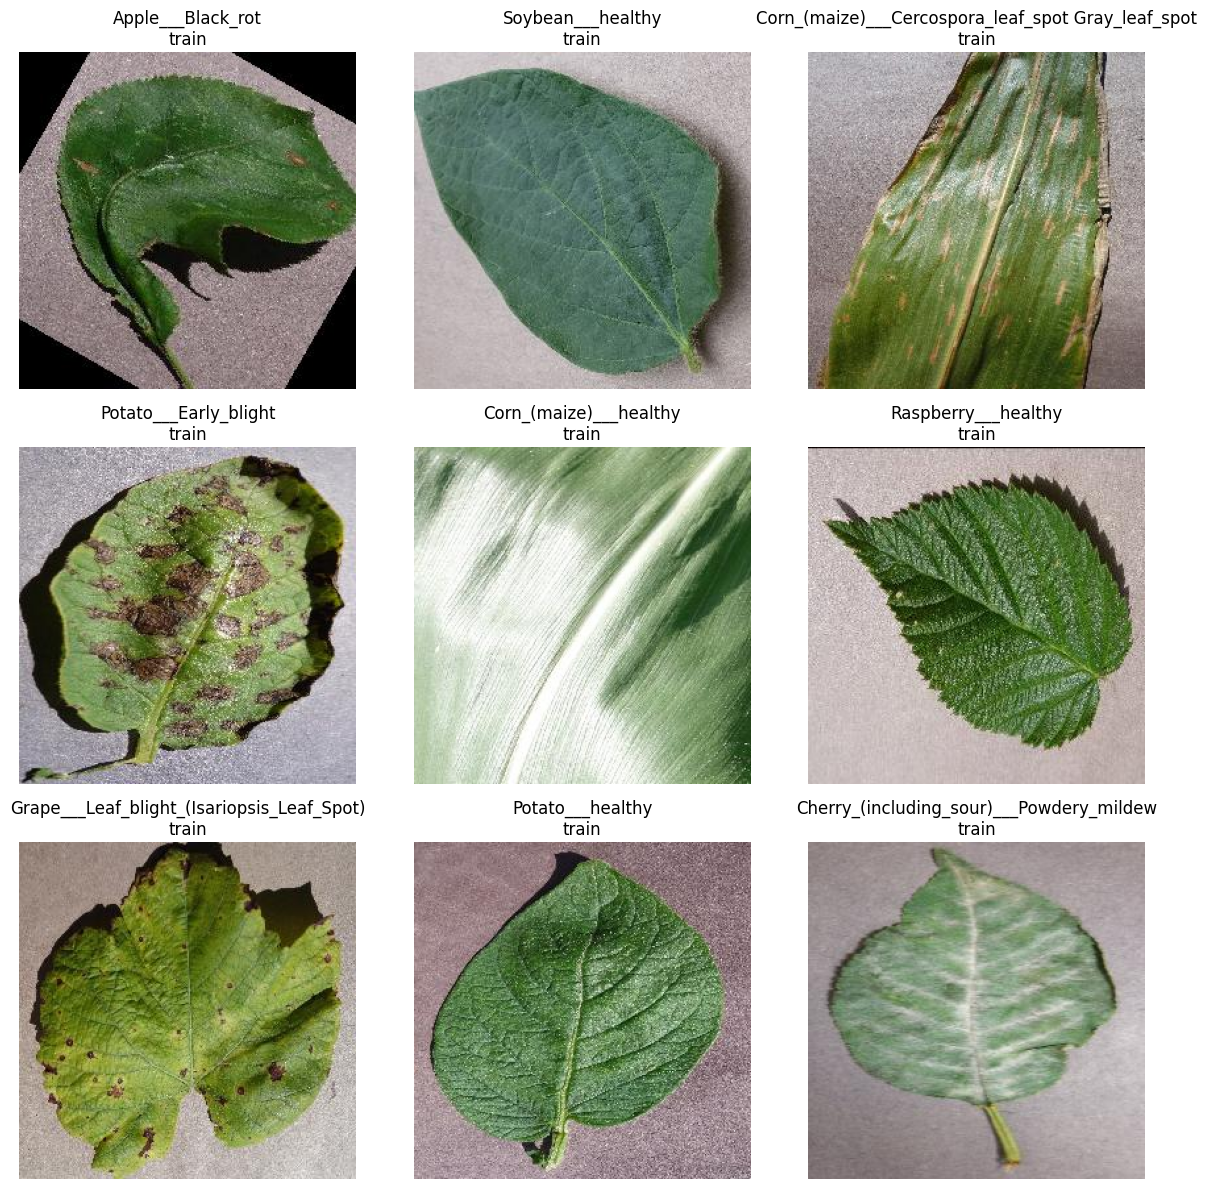

In [ ]:
# Quick visual sample by class
import random
from PIL import Image
import matplotlib.pyplot as plt

random.seed(42)

sample_classes = df["label"].dropna().unique()[:9]
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()

for i, cls in enumerate(sample_classes):
    subset = df[df["label"] == cls]
    row = subset.sample(1, random_state=42).iloc[0]
    img_path = row["image_path"]
    try:
        img = Image.open(img_path).convert("RGB")
        axes[i].imshow(img)
        axes[i].set_title(f"{cls}\n{row['split']}")
    except Exception:
        axes[i].text(0.5, 0.5, "Cannot open image", ha="center", va="center")
        axes[i].set_title(f"{cls}\n{row['split']}")
    axes[i].axis("off")

for j in range(i+1, 9):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

Ovaj prikaz daje brzu vizuelnu kontrolu kvaliteta podataka kroz nasumične primere iz prvih nekoliko klasa.
Na jednom mestu se vidi da li slike zaista prikazuju listove, da li postoje očigledne greške i koliko su primeri raznovrsni.
U naslovu svake slike stoje klasa i split, pa se lako proverava da li su oznake smisleno povezane sa sadržajem.

### 4.7 Perceptual hash duplicates
Find visually identical/almost identical images even when filenames differ.

In [13]:
import imagehash
from PIL import Image
from collections import defaultdict

def compute_multi_hash(path, hash_size=16):
    try:
        with Image.open(path).convert("RGB") as img:
            ph = str(imagehash.phash(img, hash_size=hash_size))
            ah = str(imagehash.average_hash(img, hash_size=hash_size))
            dh = str(imagehash.dhash(img, hash_size=hash_size))
            return ph, ah, dh
    except Exception:
        return np.nan, np.nan, np.nan

# Racunanje hash-eva za sve slike
tqdm.pandas(desc="Multi-hashing")
hash_results = df["image_path"].progress_apply(compute_multi_hash)
df["phash"] = hash_results.apply(lambda x: x[0])
df["ahash"] = hash_results.apply(lambda x: x[1])
df["dhash"] = hash_results.apply(lambda x: x[2])

print(f"Hashirano {len(df):,} slika sa 3 tipa hash-a (hash_size=16)")

# Exact-match duplikati po svakom hash tipu
for col in ["phash", "ahash", "dhash"]:
    counts = df[col].value_counts(dropna=True)
    dups = counts[counts > 1]
    print(f"\n{col}: {len(dups)} grupa duplikata, {int(dups.sum())} slika ukupno")


Multi-hashing:   0%|          | 0/87867 [00:00<?, ?it/s]

Hashirano 87,867 slika sa 3 tipa hash-a (hash_size=16)

phash: 32 grupa duplikata, 64 slika ukupno

ahash: 35 grupa duplikata, 71 slika ukupno

dhash: 29 grupa duplikata, 58 slika ukupno


Perceptual hash omogućava da se otkriju slike koje su vizuelno iste ili veoma slične, čak i kada imaju različita imena fajlova.

Koriste se **tri tipa hash-a** za robusnost:
- **phash** (perceptual) baziran na DCT transformaciji, hvata frekventne komponente slike
- **ahash** (average) baziran na prosječnoj vrijednosti piksela, robustan na male promjene boja
- **dhash** (difference) baziran na gradijentima susjednih piksela, robustan na promjene osvjetljenja

Povećan je `hash_size` sa 8 na 16 (256-bitni hash umjesto 64-bitnog), čime se dobija znatno preciznija detekcija.

### 4.8 RGB fingerprints
Average color signatures per class to see how separable classes look visually.

  0%|          | 0/87867 [00:00<?, ?it/s]

,r_mean,g_mean,b_mean
label,,,
Corn_(maize)___healthy,128.454145,163.275050,121.333264
Blueberry___healthy,145.799591,151.100428,140.473099
Raspberry___healthy,135.214324,146.162576,117.325577
Cherry_(including_sour)___healthy,138.505020,144.610800,121.372622
"Pepper,_bell___healthy",129.620928,143.007570,120.525445
Soybean___healthy,133.494246,142.602639,131.133135
Potato___Early_blight,136.766336,141.275964,115.381179
Strawberry___Leaf_scorch,145.357430,141.197793,118.303191
Peach___healthy,143.006816,139.255028,134.301608


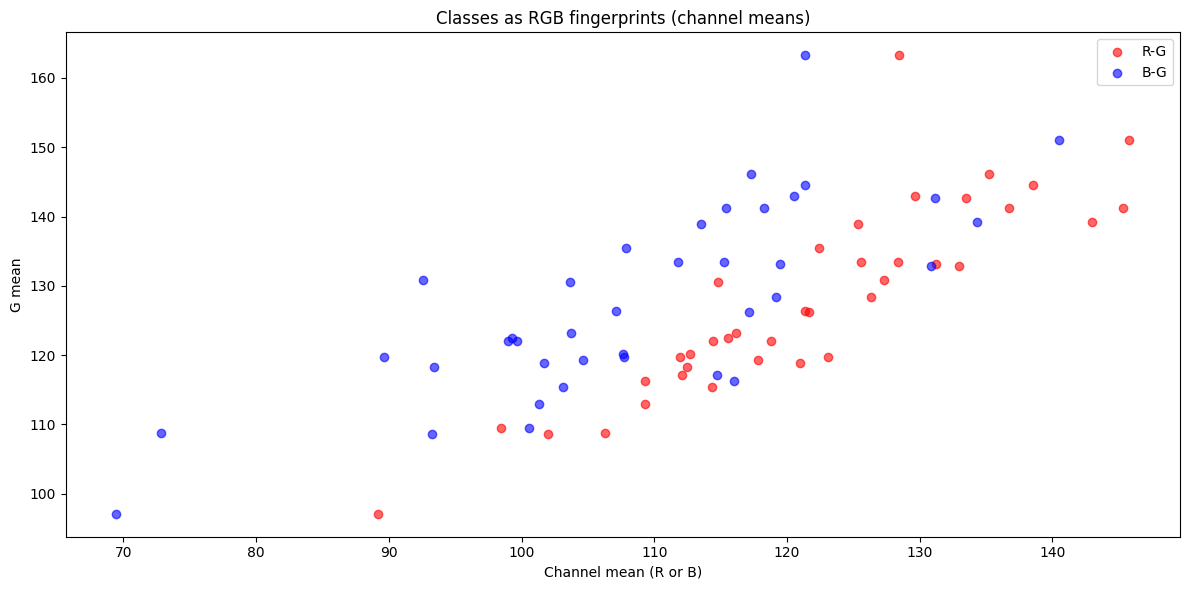

In [ ]:
def rgb_stats(path):
    try:
        img = Image.open(path).convert("RGB").resize((128,128))
        arr = np.array(img).reshape(-1, 3)
        return (
            arr[:,0].mean(), arr[:,1].mean(), arr[:,2].mean(),
            arr[:,0].std(),  arr[:,1].std(),  arr[:,2].std()
        )
    except Exception:
        return (np.nan,)*6

stats = df["image_path"].progress_apply(rgb_stats)
df[["r_mean","g_mean","b_mean","r_std","g_std","b_std"]] = pd.DataFrame(stats.tolist(), index=df.index)

class_rgb = df.groupby("label")[["r_mean","g_mean","b_mean"]].mean().sort_values("g_mean", ascending=False)
display(class_rgb.head(20))

plt.figure(figsize=(12,6))
plt.scatter(class_rgb["r_mean"], class_rgb["g_mean"], c='red', alpha=0.6, label="R-G")
plt.scatter(class_rgb["b_mean"], class_rgb["g_mean"], c='blue', alpha=0.6, label="B-G")
plt.title("Classes as RGB fingerprints (channel means)")
plt.xlabel("Channel mean (R or B)")
plt.ylabel("G mean")
plt.legend()
plt.tight_layout()
plt.show()

Analizira se prosjecna R, G i B vrijednost za svaku sliku. Nakon toga imamo grafik gde je svaka tacka jedna klasa, Y osa predstavlja prosecnu vrednost G (zelenog) kanala, a X osa prosecnu vrednost drugog kanala R ili B.
Klase gore desno oznacavaju klase koje su u proseku svetlije(vise intenziteta boja), a klase dole lijevo su tamnije klase.
Na grafiku se vidi da postoji jaka pozitivna veza: kako raste R ili B, raste i G (tacke idu dijagonalno navise). Imamo par outlier-a (npr. veoma nizak ili visok kanal mean) sto znaci da te klase mogu imati specificne uslove osvetljenja ili drugaciji vizuelni profil.

### 4.9 Brightness / Contrast shift
Check lighting shifts across splits and brightest/darkest classes.

  0%|          | 0/87867 [00:00<?, ?it/s]

Brightness/Contrast summary:


,brightness,contrast
count,87867.000000,87867.000000
mean,123.549522,40.182991
std,25.632219,11.730197
min,8.267334,6.585016
25%,109.548096,31.995681
50%,120.713440,39.652134
75%,132.039307,47.823103
max,253.313416,92.651772


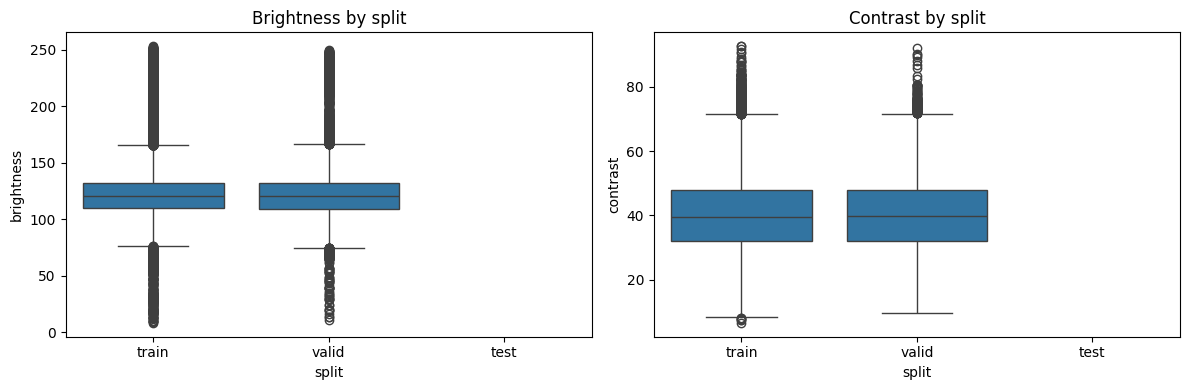

Darkest classes:


,brightness
label,
Corn_(maize)___Common_rust_,91.579796
Orange___Haunglongbing_(Citrus_greening),103.914330
Tomato___Bacterial_spot,104.919960
Apple___Apple_scab,105.162125
Tomato___Early_blight,110.510277
Tomato___Late_blight,113.654938
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot,113.736084
Tomato___Tomato_Yellow_Leaf_Curl_Virus,113.940842
Apple___healthy,114.169197


Brightest classes:


,brightness
label,
Tomato___Tomato_mosaic_virus,132.650040
"Pepper,_bell___healthy",136.440445
Potato___Early_blight,136.966187
Soybean___healthy,138.578262
Raspberry___healthy,139.623474
Strawberry___Leaf_scorch,139.821503
Peach___healthy,139.837250
Cherry_(including_sour)___healthy,140.116119
Corn_(maize)___healthy,148.070343


In [ ]:
def brightness_contrast(path):
    try:
        img = Image.open(path).convert("L").resize((128,128))
        arr = np.array(img, dtype=np.float32)
        return arr.mean(), arr.std()
    except Exception:
        return np.nan, np.nan

bc = df["image_path"].progress_apply(brightness_contrast)
df[["brightness","contrast"]] = pd.DataFrame(bc.tolist(), index=df.index)

print("Brightness/Contrast summary:")
display(df[["brightness","contrast"]].describe())

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.boxplot(data=df, x="split", y="brightness", order=["train","valid","test"])
plt.title("Brightness by split")

plt.subplot(1,2,2)
sns.boxplot(data=df, x="split", y="contrast", order=["train","valid","test"])
plt.title("Contrast by split")
plt.tight_layout()
plt.show()

# Brightest and darkest classes
class_light = df.groupby("label")["brightness"].mean().sort_values()
print("Darkest classes:")
display(class_light.head(10))
print("Brightest classes:")
display(class_light.tail(10))

Racunaju se metrike za osvetljenje (mean) i kontrast (std) na slikama.
Imamo dva grafikona koji predstavljaju osvetljenje i kontrast po klasama.
Grafik levo predstavlja osvetljenje po klasama i iz njega vidimo da je medijana za train i valid skoro ista (oko 120). Ima dosta outlier-a i ka vrlo tamnim i ka vrlo svijetlim slikama (tacke izvan tankih linija). Train i valid imaju slican nivo osvetljenja, sto je dobro.
Desni grafik predstavlja kontrast po klasama i iz njega vidimo da su medijane konstrasta za train i valid skoro iste (oko 40). Raspon u sredini je slican. Postoje outlier-i sa visokim konstrastom i nizim kontrastom. Zakljucak je da je konstrast dobro uskladjen izmedju train i valid.

### 4.10 Sharpness (blur)
Flag blurry images via Laplacian variance and list the worst cases.

  0%|          | 0/87867 [00:00<?, ?it/s]

,sharpness
count,87867.000000
mean,4361.982462
std,3572.653778
min,4.659030
25%,1410.097308
50%,3831.047426
75%,6365.915634
max,33517.246515


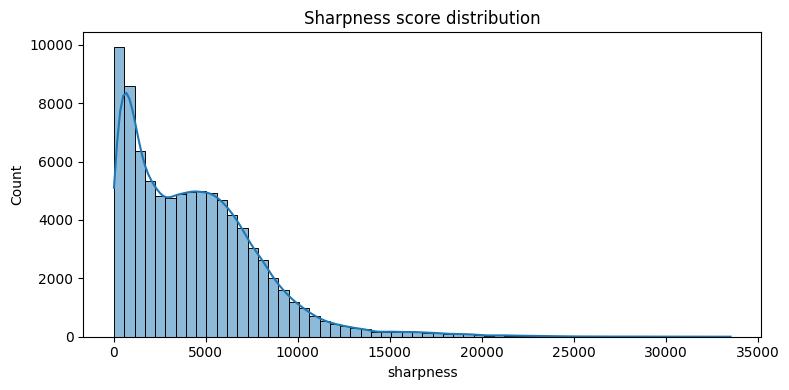

Potential blurry images (<=5th pct): 4394


,image_path,label,split,sharpness
0,/content/PlantDiseasePredictionNN/data/New Pla...,Orange___Haunglongbing_(Citrus_greening),train,79.901932
4,/content/PlantDiseasePredictionNN/data/New Pla...,Orange___Haunglongbing_(Citrus_greening),train,76.879956
7,/content/PlantDiseasePredictionNN/data/New Pla...,Orange___Haunglongbing_(Citrus_greening),train,49.237907
8,/content/PlantDiseasePredictionNN/data/New Pla...,Orange___Haunglongbing_(Citrus_greening),train,66.042245
10,/content/PlantDiseasePredictionNN/data/New Pla...,Orange___Haunglongbing_(Citrus_greening),train,75.964366
11,/content/PlantDiseasePredictionNN/data/New Pla...,Orange___Haunglongbing_(Citrus_greening),train,49.314565
15,/content/PlantDiseasePredictionNN/data/New Pla...,Orange___Haunglongbing_(Citrus_greening),train,23.344243
17,/content/PlantDiseasePredictionNN/data/New Pla...,Orange___Haunglongbing_(Citrus_greening),train,197.031827
18,/content/PlantDiseasePredictionNN/data/New Pla...,Orange___Haunglongbing_(Citrus_greening),train,104.563550
19,/content/PlantDiseasePredictionNN/data/New Pla...,Orange___Haunglongbing_(Citrus_greening),train,55.052383


In [ ]:
import cv2

def sharpness_score(path):
    try:
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            return np.nan
        return cv2.Laplacian(img, cv2.CV_64F).var()
    except Exception:
        return np.nan

df["sharpness"] = df["image_path"].progress_apply(sharpness_score)

display(df["sharpness"].describe())

plt.figure(figsize=(8,4))
sns.histplot(df["sharpness"].dropna(), bins=60, kde=True)
plt.title("Sharpness score distribution")
plt.tight_layout()
plt.show()

blur_thr = df["sharpness"].quantile(0.05)
blurred = df[df["sharpness"] <= blur_thr]
print(f"Potential blurry images (<=5th pct): {len(blurred)}")
display(blurred[["image_path","label","split","sharpness"]].head(20))

Pretvaranjem slike u crno-belu i računanjem Laplasijan varijanse postiže se izdvajanje mutnih slika iz skupa. Što je rezultat varijanse veći, slika je čistija, što je manji, slika je mutnija. Na grafiku se vidi da većina slika ima skor manji od 10000, a najviše ima onih kojima je skor blizu 0 što govori da skup sadrži dosta mutnih slika. Na osnovu toga se pronalazi granica ispod koje se nalazi 5% slika sa najlošijim skorom i prikazuje se prvih 20 iz tog skupa.

### 4.11 Leakage via phash
Detect identical content spanning different splits (potential leakage).

In [14]:
from imagehash import hex_to_hash

def find_cross_split_leakage(df, hash_col="phash", threshold=12):
    train_df = df[df["split"] == "train"].dropna(subset=[hash_col]).copy()
    valid_df = df[df["split"] == "valid"].dropna(subset=[hash_col]).copy()

    print(f"Poredim {len(train_df):,} train × {len(valid_df):,} valid slika...")
    print(f"Hash: {hash_col} | Threshold: {threshold}")

    # Grupise train slike po klasi za brze poredjenje
    train_by_class = {}
    for label, group in train_df.groupby("label"):
        train_by_class[label] = [
            (row["image_path"], hex_to_hash(row[hash_col]))
            for _, row in group.iterrows()
        ]

    leakage_pairs = []
    for _, v_row in tqdm(valid_df.iterrows(), total=len(valid_df), desc=f"Leakage ({hash_col})"):
        v_hash = hex_to_hash(v_row[hash_col])
        v_label = v_row["label"]
        # Poredi samo sa train slikama iste klase
        for t_path, t_hash in train_by_class.get(v_label, []):
            dist = t_hash - v_hash
            if dist <= threshold:
                leakage_pairs.append({
                    "train_path": t_path,
                    "valid_path": v_row["image_path"],
                    "label": v_label,
                    "distance": dist,
                })

    result_df = pd.DataFrame(leakage_pairs)

    if len(result_df) > 0:
        unique_valid = result_df["valid_path"].nunique()
        total_valid = len(valid_df)
        print(f"\nLeakage parova: {len(result_df):,}")
        print(f"Jedinstvenih valid slika sa leakage-om: {unique_valid:,} / {total_valid:,} ({100*unique_valid/total_valid:.1f}%)")
        print(f"\nDistribucija Hamming distance:")
        print(result_df["distance"].value_counts().sort_index().to_string())
    else:
        print(f"\nNije pronadjen leakage sa threshold={threshold}")

    return result_df


# Pokreni analizu za svaki hash tip
leakage_results = {}
for hash_col in ["phash", "ahash", "dhash"]:
    print(f"\n{'='*60}")
    print(f"LEAKAGE ANALIZA: {hash_col}")
    print(f"{'='*60}")
    leakage_results[hash_col] = find_cross_split_leakage(df, hash_col=hash_col, threshold=12)

# Sumiranje rezultata
all_leaked_valid = set()
for res in leakage_results.values():
    if len(res) > 0:
        all_leaked_valid.update(res["valid_path"].unique())

total_valid = len(df[df["split"] == "valid"])
print(f"\n{'='*60}")
print(f"UKUPNI LEAKAGE (unija sva 3 hash tipa)")
print(f"{'='*60}")
print(f"Valid slika sa leakage-om: {len(all_leaked_valid):,} / {total_valid:,} ({100*len(all_leaked_valid)/total_valid:.1f}%)")



LEAKAGE ANALIZA: phash
Poredim 70,295 train × 17,572 valid slika...
Hash: phash | Threshold: 12


Leakage (phash):   0%|          | 0/17572 [00:00<?, ?it/s]


Leakage parova: 160
Jedinstvenih valid slika sa leakage-om: 120 / 17,572 (0.7%)

Distribucija Hamming distance:
distance
0      7
2     14
4     28
6     26
8     35
10    26
12    24

LEAKAGE ANALIZA: ahash
Poredim 70,295 train × 17,572 valid slika...
Hash: ahash | Threshold: 12


Leakage (ahash):   0%|          | 0/17572 [00:00<?, ?it/s]


Leakage parova: 1,660
Jedinstvenih valid slika sa leakage-om: 909 / 17,572 (5.2%)

Distribucija Hamming distance:
distance
0      12
1      11
2      17
3      22
4      21
5      31
6      39
7      61
8      87
9     149
10    242
11    409
12    559

LEAKAGE ANALIZA: dhash
Poredim 70,295 train × 17,572 valid slika...
Hash: dhash | Threshold: 12


Leakage (dhash):   0%|          | 0/17572 [00:00<?, ?it/s]


Leakage parova: 174
Jedinstvenih valid slika sa leakage-om: 131 / 17,572 (0.7%)

Distribucija Hamming distance:
distance
0      7
1      2
2      6
3     11
4     11
5     19
6     22
7     23
8     22
9     17
10    10
11    15
12     9

UKUPNI LEAKAGE (unija sva 3 hash tipa)
Valid slika sa leakage-om: 934 / 17,572 (5.3%)


Za razliku od prethodne analize koja je koristila samo exact match (identične hash-eve), ovdje se koristi **Hamming distance** sa pragom od 12 bitova.

Hamming distance mjeri broj bitova razlike između dva hash-a. Slike nastale od istog originala (rotacija, flip, blaga promjena boja) tipično imaju distance 0–15, dok potpuno različite slike imaju distance 50+.

Optimizacija: porede se samo slike **iste klase**, jer leakage između različitih klasa nije moguć. Ovo drastično smanjuje broj poređenja i ubrzava analizu.

Tri tipa hash-a hvataju različite aspekte sličnosti — unija njihovih rezultata daje najpotpuniju sliku stvarnog leakage-a.

### 4.12 2D embedding of quality metrics
PCA over brightness/contrast/sharpness/aspect/area to visualize clusters and shifts.

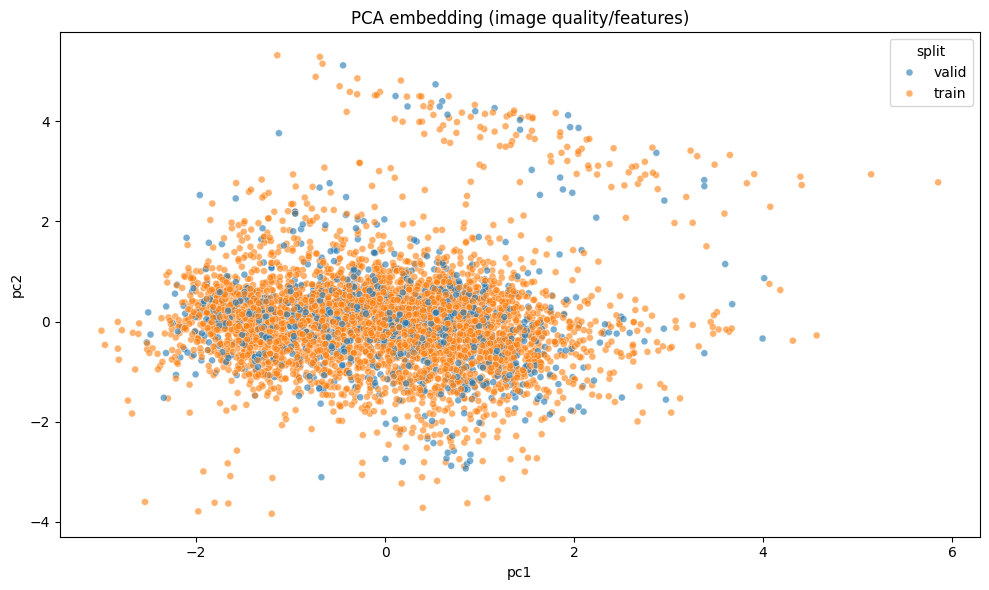

Explained variance: [0.443 0.337]


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

feat_cols = ["brightness","contrast","sharpness","aspect_ratio","img_area"]
tmp = df[feat_cols + ["label","split"]].dropna().copy()

if len(tmp) > 50:
    X = StandardScaler().fit_transform(tmp[feat_cols])
    pca = PCA(n_components=2, random_state=42)
    emb = pca.fit_transform(X)

    tmp["pc1"] = emb[:,0]
    tmp["pc2"] = emb[:,1]

    plt.figure(figsize=(10,6))
    sns.scatterplot(data=tmp.sample(min(5000, len(tmp)), random_state=42),
                    x="pc1", y="pc2", hue="split", alpha=0.6, s=25)
    plt.title("PCA embedding (image quality/features)")
    plt.tight_layout()
    plt.show()

    print("Explained variance:", pca.explained_variance_ratio_.round(3))
else:
    print("Too few samples with complete features for PCA.")

5 dimenzija odnosno osobina slika su svedene na dve dimenzije pomoću PCA. Prvo je potrebno skalirati podatke računanjem sredine i standardne devijacije kako bi se izbeglo da npr. dimenzije slike odstupaju od kontrasta, nakon čega je smanjeno posmatranje na 2 dimenzije. Na grafiku se vide narandžaste (train) i plave (valid) tačke koje se u većoj meri preklapaju što ukazuje da su slike nad kojima se trenira i validira sličnih karakteristika. Tačke koje odstupaju predstavljaju one koje su npr. tamnije od drugih, drugačije rezolucije i slično (nema ih puno).

### 4.13 Hard class indicator
Rank classes by variability in brightness/contrast/sharpness/area (higher = harder).

In [ ]:
hardness = (
    df.groupby("label")[["brightness","contrast","sharpness","img_area"]]
      .std()
      .rename(columns={
          "brightness":"brightness_std",
          "contrast":"contrast_std",
          "sharpness":"sharpness_std",
          "img_area":"area_std"
      })
)

hardness["hardness_score"] = (
    hardness["brightness_std"].fillna(0)*0.25 +
    hardness["contrast_std"].fillna(0)*0.25 +
    hardness["sharpness_std"].fillna(0)*0.35 +
    hardness["area_std"].fillna(0)*0.15
)

hardness = hardness.sort_values("hardness_score", ascending=False)
print("Top 15 potentially hard classes:")
display(hardness.head(15))

Top 15 potentially hard classes:


,brightness_std,contrast_std,sharpness_std,area_std,hardness_score
label,,,,,
Tomato___healthy,32.321186,12.360472,7004.600233,0.0,2462.780496
Squash___Powdery_mildew,13.495648,5.562908,3514.914001,0.0,1234.984539
Soybean___healthy,16.449783,5.666700,3395.542243,0.0,1193.968906
Raspberry___healthy,40.108379,9.600701,3307.541424,0.0,1170.066768
"Pepper,_bell___healthy",34.338490,9.887790,3236.373785,0.0,1143.787395
Tomato___Septoria_leaf_spot,16.220936,9.728630,3183.910267,0.0,1120.855985
Apple___Apple_scab,16.588827,12.000781,3156.544134,0.0,1111.937849
Potato___healthy,30.195971,9.503667,2920.031467,0.0,1031.935923
Apple___Black_rot,12.729895,8.726913,2894.724913,0.0,1018.517922


Računanjem standardne devijacije se provera sličnost slika po klasama. 35% težine sa oštrinu jer mutne slike najviše bune model, pod 25% je za osvetljenost i kontrast i 15% za površinu slike jer najmanje ima uticaja. Na osnovu rezultata vidimo da postoje klase koje sadrže sliče slike, ali i one koje imaju slike nastale u različitim uslovima.


### 4.14 Colorfulness score
Quantifies how vivid each image is to spot unusually dull samples or class-level color differences that might hint at acquisition issues or mislabeled data.

  0%|          | 0/87867 [00:00<?, ?it/s]

Colorfulness summary:


,colorfulness
count,87867.000000
mean,28.226425
std,11.033097
min,3.947388
25%,20.910345
50%,26.204636
75%,32.803158
max,99.352036


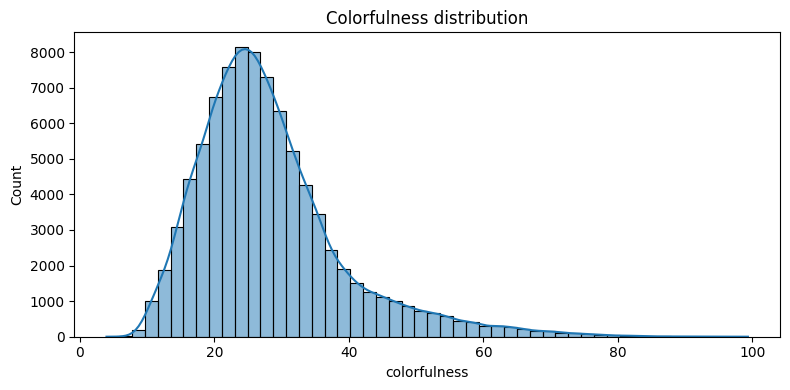

Top 10 least colorful classes:


,colorfulness
label,
Peach___healthy,13.918798
Apple___healthy,18.096252
Soybean___healthy,18.464622
Tomato___Target_Spot,19.066730
Tomato___healthy,19.586563
Tomato___Spider_mites Two-spotted_spider_mite,20.178614
Tomato___Early_blight,22.341562
Tomato___Bacterial_spot,23.527361
Potato___Late_blight,23.956272


In [ ]:
from tqdm.auto import tqdm
tqdm.pandas()

def colorfulness_score(path):
    try:
        img = Image.open(path).convert("RGB")
        arr = np.asarray(img).astype("float32")
        (R, G, B) = arr[...,0], arr[...,1], arr[...,2]
        rg = np.abs(R - G)
        yb = np.abs(0.5*(R + G) - B)
        std_rg, std_yb = np.std(rg), np.std(yb)
        mean_rg, mean_yb = np.mean(rg), np.mean(yb)
        return np.sqrt(std_rg**2 + std_yb**2) + 0.3*np.sqrt(mean_rg**2 + mean_yb**2)
    except Exception:
        return np.nan

df["colorfulness"] = df["image_path"].progress_apply(colorfulness_score)

print("Colorfulness summary:")
display(df["colorfulness"].describe())

plt.figure(figsize=(8,4))
sns.histplot(df["colorfulness"].dropna(), bins=50, kde=True)
plt.title("Colorfulness distribution")
plt.tight_layout()
plt.show()

print("Top 10 least colorful classes:")
display(df.groupby("label")["colorfulness"].mean().sort_values().head(10))

Grafik pokazuje da većina slika ima umerenu živost boja što je i očekivano s obzirom da se radi o slikama na kojima uglavnom preovladava zelena boja. Postoji nekolicina slika koje su šarene i to se slike bolesnih biljaka gde se raspon boja proteže od žute do zelene uz smeđu, crvu, crvenu itd. Mali broj slika predstavljaju blede uzorke i kod daje 10 najbleđih na osvonu čega može da se analizira skup i uvidi da li su te slike dobre za analizu ili su slikane u lošim uslovima.


### 4.15 Dominant hue analysis
Extracts the most common hue per image in HSV space to see if certain classes cluster around specific color tones (e.g., yellow/brown for diseased leaves).

  0%|          | 0/87867 [00:00<?, ?it/s]

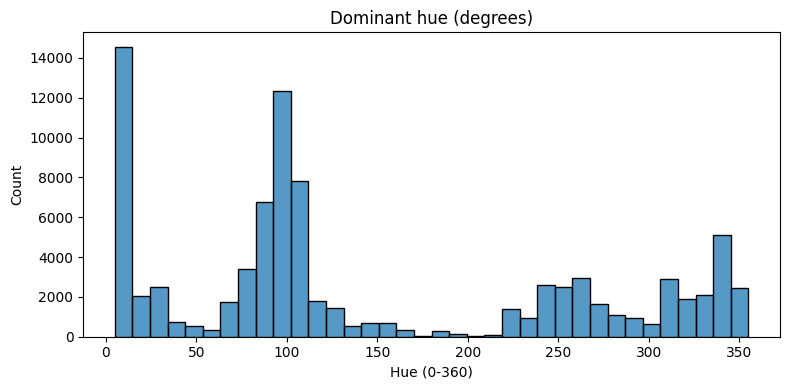

,dominant_hue_deg
label,
Grape___Esca_(Black_Measles),5.0
Corn_(maize)___Common_rust_,5.0
Apple___Cedar_apple_rust,35.0
Grape___Leaf_blight_(Isariopsis_Leaf_Spot),75.0
Orange___Haunglongbing_(Citrus_greening),75.0
Cherry_(including_sour)___Powdery_mildew,85.0
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot,85.0
Potato___Early_blight,85.0
Tomato___Bacterial_spot,85.0


,dominant_hue_deg
label,
Soybean___healthy,125.0
Apple___Black_rot,125.0
Tomato___Late_blight,225.0
Tomato___Leaf_Mold,225.0
Apple___healthy,225.0
Peach___Bacterial_spot,235.0
Apple___Apple_scab,235.0
Tomato___Early_blight,245.0
Blueberry___healthy,265.0


In [ ]:
import colorsys

def dominant_hue(path, bins=36):
    try:
        img = Image.open(path).convert("RGB").resize((128,128))
        arr = np.asarray(img).reshape(-1,3) / 255.0
        hsv = np.array([colorsys.rgb_to_hsv(*pix) for pix in arr])
        hue = hsv[:,0]  # [0,1]
        hist, edges = np.histogram(hue, bins=bins, range=(0,1))
        idx = np.argmax(hist)
        hue_center = 0.5*(edges[idx] + edges[idx+1])
        return hue_center * 360.0
    except Exception:
        return np.nan

df["dominant_hue_deg"] = df["image_path"].progress_apply(dominant_hue)

plt.figure(figsize=(8,4))
sns.histplot(df["dominant_hue_deg"].dropna(), bins=36, kde=False)
plt.title("Dominant hue (degrees)")
plt.xlabel("Hue (0-360)")
plt.tight_layout()
plt.show()

hue_by_class = df.groupby("label")["dominant_hue_deg"].median().sort_values()
display(hue_by_class.head(15))
display(hue_by_class.tail(15))

Na osnovu pretvaranja slike u hsv odvaja se boja od kontrasta i osvetljenosti što na grafiku daje histogram na kome se vidi da su dominante zelena, crvena i smeđa jer su vrednosti na grafiku najveće za 0 i 360 stepeni (crvena i smeđa boja) i za 80-120 stepeni (zelena). Ukazuje da imamo slike zdravih biljaka i onih kod kojih je bolest napredovala. Vrednosti između 150 i 250 stepeni su male što je dobar pokazatelj da na slikama nemamo boje koje nisu uobičajne za slike listoca (plava, tirkizna).

### 4.16 Edge density (Canny)
Measures the proportion of edge pixels to capture leaf texture/veins; helpful for spotting classes with strong or weak structural detail.

  0%|          | 0/87867 [00:00<?, ?it/s]

Edge density summary:


,edge_density
count,87867.000000
mean,0.132860
std,0.074329
min,0.000000
25%,0.067459
50%,0.135376
75%,0.188751
max,0.354736


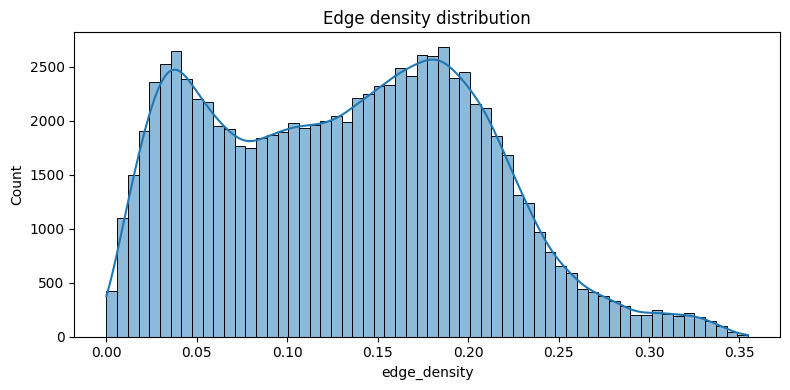

Classes with the highest average texture:


,edge_density
label,
Tomato___healthy,0.229843
Potato___healthy,0.207804
Potato___Early_blight,0.203664
Tomato___Spider_mites Two-spotted_spider_mite,0.197449
Strawberry___healthy,0.196760
Tomato___Target_Spot,0.196030
Grape___Esca_(Black_Measles),0.185844
Strawberry___Leaf_scorch,0.184182
Tomato___Tomato_mosaic_virus,0.183890


In [ ]:
import cv2

def edge_density(path):
    try:
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            return np.nan
        img = cv2.resize(img, (256,256))
        edges = cv2.Canny(img, 100, 200)
        return edges.mean() / 255.0
    except Exception:
        return np.nan

df["edge_density"] = df["image_path"].progress_apply(edge_density)

print("Edge density summary:")
display(df["edge_density"].describe())

plt.figure(figsize=(8,4))
sns.histplot(df["edge_density"].dropna(), bins=60, kde=True)
plt.title("Edge density distribution")
plt.tight_layout()
plt.show()

print("Classes with the highest average texture:")
display(df.groupby("label")["edge_density"].mean().sort_values(ascending=False).head(10))

Na osnovu Cannya koji detektuje ivice na grafiku se vide dva brda, prvo brdo oko vrednosti 0.4 koje ukazuje da imamo dosta slika sa jako malo detalja, što zapravo slike zdravih listova i jesu, a drugo brdo oko 0.18 su slike sa više tekstura i u njih spadaju slike bolesnih listova. Na osnovu ove analize, mogu se klasifikovati bolesti listova koje su slične, ali jedna prouzrokuje sitne pege, a druga bled list.


### 4.17 Near-monochrome detector
Flags images with very low saturation that might be grayscale scans, sensor failures, or artifacts needing review.

In [ ]:
def saturation_mean(path):
    try:
        img = Image.open(path).convert("RGB").resize((128,128))
        arr = np.asarray(img).astype(np.float32) / 255.0
        hsv = cv2.cvtColor((arr*255).astype(np.uint8), cv2.COLOR_RGB2HSV)
        s = hsv[...,1].astype(np.float32) / 255.0
        return s.mean()
    except Exception:
        return np.nan

df["sat_mean"] = df["image_path"].progress_apply(saturation_mean)

mono_thr = 0.08
df["near_monochrome"] = df["sat_mean"] < mono_thr

print(f"Near-monochrome (<{mono_thr}) %:", round(df["near_monochrome"].mean()*100, 2))
display(df.groupby("split")["near_monochrome"].mean().mul(100).round(2))

mono_examples = df[df["near_monochrome"]].head(20)
display(mono_examples[["image_path","label","split","sat_mean"]])

  0%|          | 0/87867 [00:00<?, ?it/s]

Near-monochrome (<0.08) %: 0.48


,near_monochrome
split,
train,0.47
valid,0.50


,image_path,label,split,sat_mean
2230,/content/PlantDiseasePredictionNN/data/New Pla...,"Pepper,_bell___healthy",train,0.021418
2398,/content/PlantDiseasePredictionNN/data/New Pla...,"Pepper,_bell___healthy",train,0.066481
3225,/content/PlantDiseasePredictionNN/data/New Pla...,"Pepper,_bell___healthy",train,0.074079
3266,/content/PlantDiseasePredictionNN/data/New Pla...,"Pepper,_bell___healthy",train,0.079010
3637,/content/PlantDiseasePredictionNN/data/New Pla...,"Pepper,_bell___healthy",train,0.068589
3753,/content/PlantDiseasePredictionNN/data/New Pla...,"Pepper,_bell___healthy",train,0.072572
6356,/content/PlantDiseasePredictionNN/data/New Pla...,Soybean___healthy,train,0.055541
13244,/content/PlantDiseasePredictionNN/data/New Pla...,Apple___Cedar_apple_rust,train,0.051165
13265,/content/PlantDiseasePredictionNN/data/New Pla...,Apple___Cedar_apple_rust,train,0.026196
13315,/content/PlantDiseasePredictionNN/data/New Pla...,Apple___Cedar_apple_rust,train,0.049846


Na osnovu S kanala iz HSVa dobija se informacija o slikama koje su monohromatske odnosno one koje nemaju dovoljno informacija o bojama. Svaka slika kod koje je sat_mean manji od 0.08 je slika koja može loše da utiče na model jer ne oslikava realne boje koje model treba da nauči.

### 4.18 Background ratio estimation
Estimates the share of bright background pixels to find classes or images with strong studio-like backdrops that could bias the model.

  0%|          | 0/87867 [00:00<?, ?it/s]

,bg_ratio
count,87867.000000
mean,0.024106
std,0.111616
min,0.000000
25%,0.000000
50%,0.000443
75%,0.003143
max,0.974197


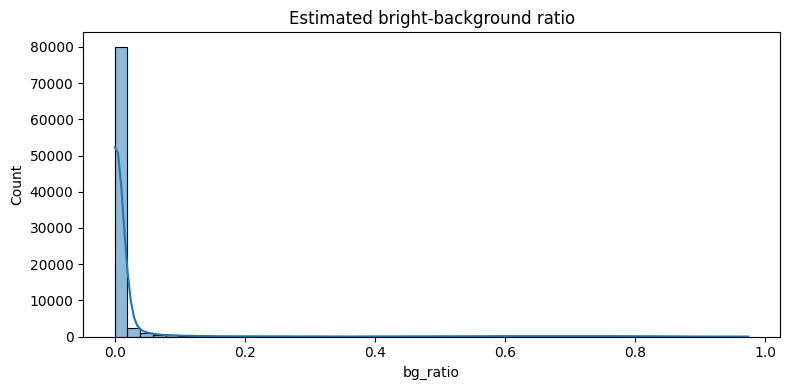

Classes with highest background ratio:


,bg_ratio
label,
Peach___healthy,0.131562
Tomato___Tomato_mosaic_virus,0.118298
Blueberry___healthy,0.115383
Raspberry___healthy,0.091523
Apple___Cedar_apple_rust,0.074659
"Pepper,_bell___healthy",0.070537
Tomato___Target_Spot,0.067016
Tomato___healthy,0.061374
Potato___healthy,0.043869


In [ ]:
def background_ratio(path):
    try:
        img = Image.open(path).convert("RGB").resize((256,256))
        arr = np.asarray(img).astype(np.float32) / 255.0
        bright = (arr[...,0] > 0.85) & (arr[...,1] > 0.85) & (arr[...,2] > 0.85)
        return bright.mean()
    except Exception:
        return np.nan

df["bg_ratio"] = df["image_path"].progress_apply(background_ratio)

display(df["bg_ratio"].describe())

plt.figure(figsize=(8,4))
sns.histplot(df["bg_ratio"].dropna(), bins=50, kde=True)
plt.title("Estimated bright-background ratio")
plt.tight_layout()
plt.show()

print("Classes with highest background ratio:")
display(df.groupby("label")["bg_ratio"].mean().sort_values(ascending=False).head(10))

Grafik prikazuje da većina slika nema belu pozadinu što je dobar znak jer model uči nad slikama koje nemaju jasnu razliku između bele pozadine i zelenog lista.


### 4.19 Class visual prototypes (median images)
Creates a median-pixel prototype per top class for a quick visual sanity check of dominant shapes/colors and potential anomalies.

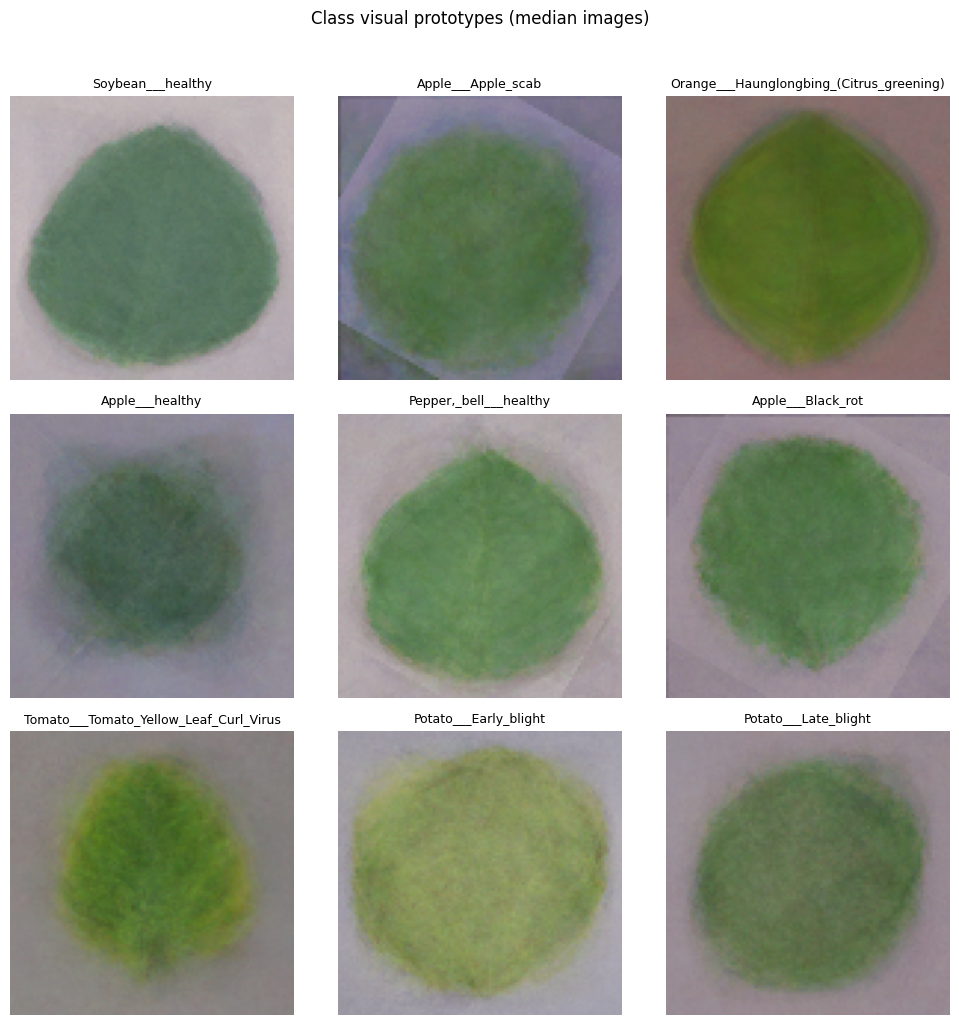

In [ ]:
def class_median_image(paths, size=(96,96), max_samples=40):
    sample_paths = list(paths[:max_samples])
    imgs = []
    for p in sample_paths:
        try:
            img = Image.open(p).convert("RGB").resize(size)
            imgs.append(np.asarray(img, dtype=np.float32))
        except Exception:
            pass
    if len(imgs) == 0:
        return None
    med = np.median(np.stack(imgs, axis=0), axis=0).astype(np.uint8)
    return med

top_classes = df["label"].value_counts().head(9).index.tolist()
fig, axes = plt.subplots(3,3, figsize=(10,10))
axes = axes.flatten()

for i, cls in enumerate(top_classes):
    paths = df[df["label"] == cls]["image_path"].values
    med = class_median_image(paths, size=(96,96), max_samples=50)
    if med is not None:
        axes[i].imshow(med)
    axes[i].set_title(cls, fontsize=9)
    axes[i].axis("off")

for j in range(i+1,9):
    axes[j].axis("off")

plt.suptitle("Class visual prototypes (median images)", y=1.02)
plt.tight_layout()
plt.show()

Tehnikom slaganja slika jedne klase jednu na drugu za svaki piksel traži se medijana. Na osnovu rezultata ovog koda, vidi se kod apple_scab i black_rot da u toj klasi verovatno ima dosta istih slika koje su samo zarotirane, a kod tomato_yellow_leaf_curl_virus se vidi svetlija boja što potvrđuje da boja u ovoj analizi igra ulogu.

### 4.20 Filename semantics mining
Tokenizes filenames to surface hints of augmented/synthetic data (e.g., "flip", "rot", "copy") that could indicate leakage or artifacts.

In [ ]:
import re
from collections import Counter

def filename_tokens(path):
    fname = path.split("/")[-1].lower()
    fname = re.sub(r"\.[a-z0-9]+$", "", fname)  # ukloni ekstenziju
    toks = re.split(r"[_\-\s\.]+", fname)
    toks = [t for t in toks if len(t) >= 3 and not t.isdigit()]
    return toks

counter = Counter()
for p in df["image_path"].astype(str):
    counter.update(filename_tokens(p))

top_tokens = pd.DataFrame(counter.most_common(40), columns=["token","count"])
display(top_tokens)

suspicious = ["aug", "flip", "rot", "copy", "crop", "enhance", "bright", "blur"]
print("Suspicious tokens:")
display(top_tokens[top_tokens["token"].isin(suspicious)])

,token,count
0,fliplr,8681
1,180deg,8668
2,fliptb,7275
3,fam,6912
4,frec,6824
5,new30degfliplr,5042
6,rust,4584
7,com,4460
8,270deg,4174
9,90deg,4174


Suspicious tokens:


,token,count
12,copy,2917
26,rot,2360


Rezultat ovoga pokazuje da je većina slika u ovom datasetu nastala kao posledica augmentacije. Model ovim ima više primera da nauči.